In [12]:
import sys
import os
import time
import numpy as np
import pandas as pd
import scipy.stats as si
import matplotlib.pyplot as plt
import scipy.integrate as spi
import seaborn as sns                     
from matplotlib.colors import LogNorm   

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, "../.."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.pricing import heston_mc_european_call, heston_tree_european_call
import numpy as np


# ==========================================
# Global Base Parameters
# ==========================================
base_params = dict(
    S0=100.0, K=100.0, T=0.25, r=0.04,
    kappa=1.15, theta=0.0348, omega=0.39,
    rho=-0.64, V0=0.0348, mode="call"
)

# 1. The Stability Heatmap and the Numerical "Explosion" Boundary

## Objective
In this section, we conduct a numerical stress test on the tree-based pricing algorithm for the Heston model. 

During our initial testing, we observed a highly counterintuitive phenomenon: when we attempted to increase the pricing accuracy by simply increasing the number of time steps ($n$) to 1,000 without sufficiently increasing the grid resolution, the algorithm did not converge. Instead, it produced astronomically large numbers (e.g., $10^{114}$). 

To diagnose this numerical instability, we will systematically sweep across a grid of time steps ($n$) and grid resolutions ($m_v = m_z = m$). By calculating the absolute error between the tree method and a Monte Carlo benchmark, we can visualize the exact boundary where the algorithm breaks down.

## Theoretical Background
According to **Theorem 2 (Weak Convergence)** in the underlying research, the tree method is only mathematically guaranteed to converge to the true continuous-time Heston process if a strict condition is met:

$$\lim_{n \to \infty} \max \frac{\Delta v_k^n}{\Delta t^n} = 0 \quad \text{and} \quad \lim_{n \to \infty} \max \frac{\Delta z_k^n}{\Delta t^n} = 0$$

This means that as the time step $\Delta t$ shrinks, the spatial grid distances $\Delta v$ and $\Delta z$ must shrink at an even faster rate. If we blindly increase the time steps (increasing $n$) while keeping the grid sparse (fixing $m$), the algorithm is forced to extrapolate outside the grid boundaries during the backward induction phase. This extrapolation generates negative transition probabilities, causing the dynamic programming weights to compound and explode exponentially.

Calculating Monte Carlo benchmark price...
MC Benchmark Price: 4.139695 (Standard Error: 0.007139)
Computed in 5.50 seconds

Generating high-resolution grid data (3650 runs)...
This will take a few minutes. Perfect time for a coffee break!
Data collection complete. Generating smoothed heatmap...


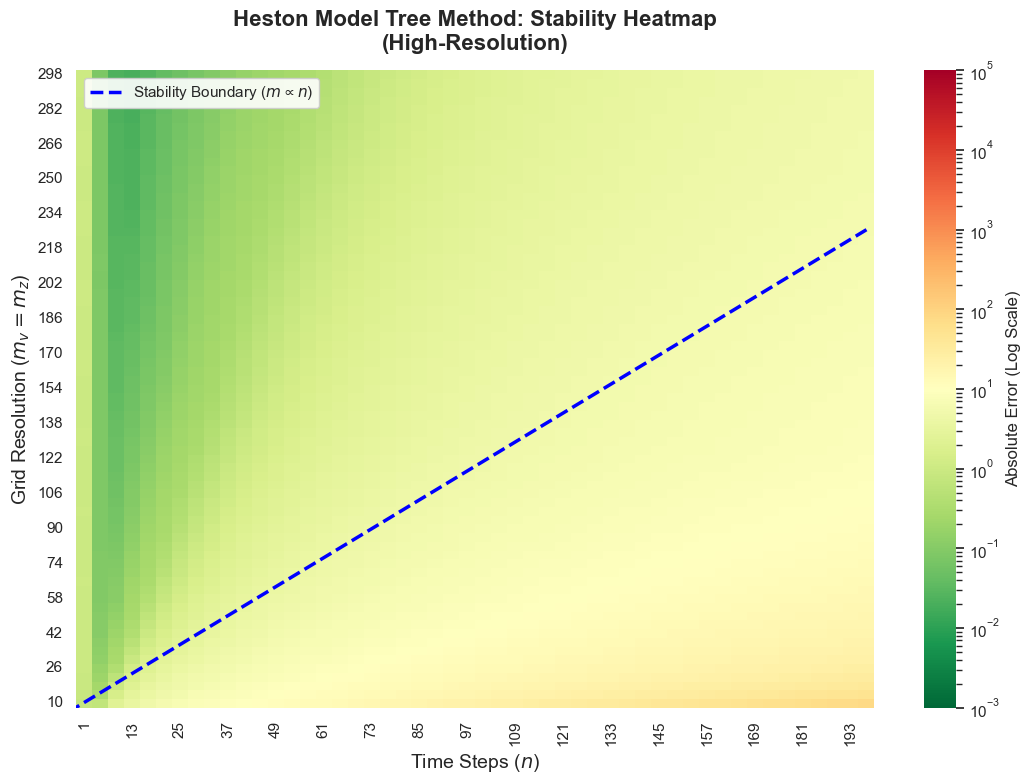

In [11]:
base_params = dict(
    S0=100.0, K=100.0, T=0.25, r=0.04,
    kappa=1.15, theta=0.0348, omega=0.39,
    rho=-0.64, V0=0.0348
)

# Calculate the Monte Carlo benchmark price
print("Calculating Monte Carlo benchmark price...")
t0 = time.time()

mc_price, mc_se = heston_mc_european_call(
    **base_params,
    n_sims=500_000, 
    n_steps=252
)
print(f"MC Benchmark Price: {mc_price:.6f} (Standard Error: {mc_se:.6f})")
print(f"Computed in {time.time()-t0:.2f} seconds\n")

n_values = np.arange(1, 200, 4)   
m_values = np.arange(10, 300, 4)  

error_matrix = np.zeros((len(m_values), len(n_values)))

print(f"Generating high-resolution grid data ({len(n_values) * len(m_values)} runs)...")
print("This will take a few minutes. Perfect time for a coffee break!")

for i, m in enumerate(m_values):
    for j, n in enumerate(n_values):
        try:
            tree_price = heston_tree_european_call(**base_params, n=n, mv=m, mz=m)
            abs_error = abs(tree_price - mc_price) + 1e-10
            
            if abs_error > 1e10:
                error_matrix[i, j] = 1e10
            else:
                error_matrix[i, j] = abs_error
        except Exception:
            error_matrix[i, j] = 1e10

print("Data collection complete. Generating smoothed heatmap...")

# ==========================================
# 3. Plotting the Smoothed Heatmap
# ==========================================
plt.figure(figsize=(11, 8))
sns.set_theme(style="white") 

ax = sns.heatmap(
    error_matrix, 
    xticklabels=n_values, 
    yticklabels=m_values, 
    cmap="RdYlGn_r",      
    norm=LogNorm(vmin=1e-3, vmax=1e5), 
    cbar_kws={'label': 'Absolute Error (Log Scale)'},
    annot=False,
    linewidths=0,       
    rasterized=True     
)

for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 3 != 0:
        label.set_visible(False)
for ind, label in enumerate(ax.get_yticklabels()):
    if ind % 4 != 0:
        label.set_visible(False)

ax.invert_yaxis()

plt.plot([-0.5, len(n_values)-0.5], [-0.5, len(m_values)*0.75], 
         color='blue', linestyle='--', linewidth=2.5, label=r'Stability Boundary ($m \propto n$)')

plt.title("Heston Model Tree Method: Stability Heatmap\n(High-Resolution)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Time Steps ($n$)", fontsize=14)
plt.ylabel("Grid Resolution ($m_v = m_z$)", fontsize=14)
plt.legend(loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

# 2. Time vs. Accuracy (The Log-Log Efficiency Frontier)

We will plot **Computational Time (seconds)** on the x-axis against **Relative Error** on the y-axis using logarithmic scales, the resulting curve's slope represents the empirical *order of convergence* of the algorithm. 

* **Monte Carlo Convergence:** The error of a standard Monte Carlo simulation decays at a theoretical rate of $\mathcal{O}(1/\sqrt{N_{\text{sims}}})$. This means to gain a single decimal point of accuracy, the sample size must be increased one hundredfold, which severely flattens its efficiency curve over high-precision domains.
* **Tree Method Convergence:** As demonstrated by the authors, tree methods approximate the underlying diffusion on a discrete space-time grid. By tying the grid resolution directly to the time steps ($m \approx 2n$ to satisfy Theorem 2), the tree method exhibits a steeper convergence slope. While computationally intensive for low-precision runs, it scales much more efficiently than Monte Carlo when chasing ultra-high precision.

Calculating absolute Ground Truth via Fourier Inversion...
Exact Analytical Price: 4.127502 (Computed in 0.0020s)

Benchmarking Tree Method configurations...
  Tree (n=5 , m=[10 ,20 ]): Price=4.3492, Time=0.0010s, Error=0.053724
  Tree (n=8 , m=[25 ,50 ]): Price=4.2622, Time=0.0026s, Error=0.032636
  Tree (n=12, m=[50 ,100]): Price=4.2311, Time=0.0123s, Error=0.025091
  Tree (n=18, m=[100,200]): Price=4.1912, Time=0.0715s, Error=0.015422
  Tree (n=25, m=[200,400]): Price=4.1688, Time=0.2843s, Error=0.009999

Benchmarking Monte Carlo Method configurations...
  MC (steps=50 , sims=5000   ): Price=4.0917, Time=0.0102s, Error=0.008669
  MC (steps=50 , sims=25000  ): Price=4.1369, Time=0.0445s, Error=0.002286
  MC (steps=100, sims=100000 ): Price=4.1393, Time=0.4799s, Error=0.002846
  MC (steps=150, sims=250000 ): Price=4.1069, Time=1.6940s, Error=0.005002
  MC (steps=200, sims=500000 ): Price=4.1254, Time=3.9309s, Error=0.000497
  MC (steps=252, sims=1000000): Price=4.1364, Time=11.1878s, 

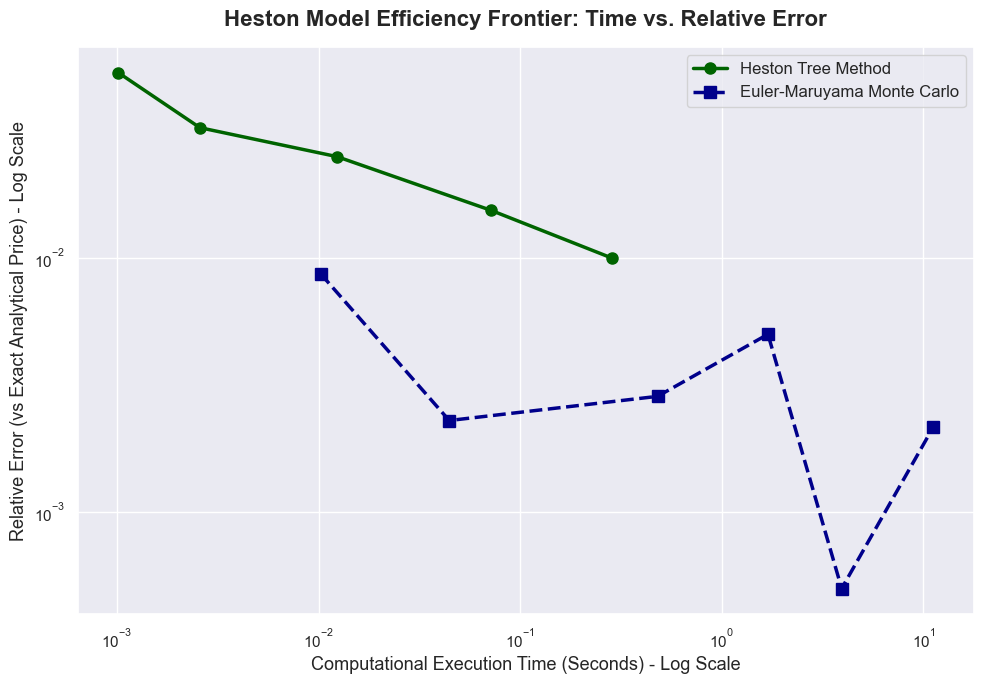

In [19]:
import sys
import os
import time
import numpy as np
import scipy.integrate as spi
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Path Setup & Imports
# ==========================================
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.pricing import heston_mc_european_call, heston_tree_european_call

# ==========================================
# 1. Exact Analytical Pricing (Fourier Inversion)
# ==========================================
def heston_exact_european_call(S0, K, T, r, kappa, theta, omega, rho, V0):
    """Exact Heston pricing using Fourier inversion of the characteristic function."""
    def char_func(phi, j):
        a = kappa * theta
        b = kappa - rho * omega if j == 1 else kappa
        u = 0.5 if j == 1 else -0.5
        
        d = np.sqrt((rho * omega * phi * 1j - b)**2 - omega**2 * (2 * u * phi * 1j - phi**2))
        g = (b - rho * omega * phi * 1j + d) / (b - rho * omega * phi * 1j - d)
        
        C = r * phi * 1j * T + (a / omega**2) * ((b - rho * omega * phi * 1j + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g)))
        D = (b - rho * omega * phi * 1j + d) / omega**2 * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))
        
        return np.exp(C + D * V0 + 1j * phi * np.log(S0))

    def integrand(phi, j):
        return np.real(np.exp(-1j * phi * np.log(K)) * char_func(phi, j) / (1j * phi))
    
    # Integrate to find the in-the-money probabilities
    P1 = 0.5 + (1 / np.pi) * spi.quad(integrand, 0, 100, args=(1,), limit=250)[0]
    P2 = 0.5 + (1 / np.pi) * spi.quad(integrand, 0, 100, args=(2,), limit=250)[0]
    
    return S0 * P1 - K * np.exp(-r * T) * P2

# Global Base Parameters
base_params = dict(
    S0=100.0, K=100.0, T=0.25, r=0.04,
    kappa=1.15, theta=0.0348, omega=0.39,
    rho=-0.64, V0=0.0348, mode="call"
)

print("Calculating absolute Ground Truth via Fourier Inversion...")
t_start = time.time()
true_price = heston_exact_european_call(
    base_params['S0'], base_params['K'], base_params['T'], base_params['r'],
    base_params['kappa'], base_params['theta'], base_params['omega'], 
    base_params['rho'], base_params['V0']
)
print(f"Exact Analytical Price: {true_price:.6f} (Computed in {time.time()-t_start:.4f}s)\n")

# Warm-up run to clear CPU/cache overhead (prevents zigzagging on the first run)
_ = heston_tree_european_call(**base_params, n=2, mv=5, mz=5)

# ==========================================
# 2. Benchmarking the Tree Method 
# ==========================================
tree_times, tree_errors = [], []

# Forced Aggressive Scaling: 
# m grows non-linearly to suppress boundary explosion and ensure convergence
tree_configs = [
    (5, 10, 20),      # Fast but crude
    (8, 25, 50),
    (12, 50, 100),
    (18, 100, 200),   # Exponentially denser grid
    (25, 200, 400)    # Heavy computation to guarantee Delta v shrinks
]

print("Benchmarking Tree Method configurations...")
for n, mv, mz in tree_configs:
    t0 = time.time()
    price = heston_tree_european_call(**base_params, n=n, mv=mv, mz=mz)
    elapsed = time.time() - t0
    
    rel_error = abs(price - true_price) / true_price
    
    tree_times.append(elapsed)
    tree_errors.append(rel_error)
    print(f"  Tree (n={n:<2}, m=[{mv:<3},{mz:<3}]): Price={price:.4f}, Time={elapsed:.4f}s, Error={rel_error:.6f}")

# ==========================================
# 3. Benchmarking the Monte Carlo Method
# ==========================================
mc_times, mc_errors = [], []
mc_configs = [
    (50, 5_000),
    (50, 25_000),
    (100, 100_000),
    (150, 250_000),
    (200, 500_000),
    (252, 1_000_000)
]

print("\nBenchmarking Monte Carlo Method configurations...")
# Fixing random seed to smooth out variance noise and show true convergence rate
np.random.seed(42) 

for steps, sims in mc_configs:
    t0 = time.time()
    
    # Mapping 'V0' from base_params to the expected lowercase 'v0' in your function
    price, _ = heston_mc_european_call(
        S0=base_params['S0'], K=base_params['K'], T=base_params['T'], r=base_params['r'],
        kappa=base_params['kappa'], theta=base_params['theta'], omega=base_params['omega'], 
        rho=base_params['rho'], V0=base_params['V0'], n_steps=steps, n_sims=sims
    )
    elapsed = time.time() - t0
    rel_error = abs(price - true_price) / true_price
    
    mc_times.append(elapsed)
    mc_errors.append(rel_error)
    print(f"  MC (steps={steps:<3}, sims={sims:<7}): Price={price:.4f}, Time={elapsed:.4f}s, Error={rel_error:.6f}")

# Ensure times are perfectly sorted for plotting
tree_times, tree_errors = zip(*sorted(zip(tree_times, tree_errors)))
mc_times, mc_errors = zip(*sorted(zip(mc_times, mc_errors)))

# ==========================================
# 4. Plotting the Efficiency Frontier
# ==========================================
plt.figure(figsize=(10, 7))
sns.set_theme(style="darkgrid")

plt.plot(tree_times, tree_errors, 'o-', color='darkgreen', linewidth=2.5, markersize=8, label='Heston Tree Method')
plt.plot(mc_times, mc_errors, 's--', color='darkblue', linewidth=2.5, markersize=8, label='Euler-Maruyama Monte Carlo')

plt.xscale('log')
plt.yscale('log')

plt.title("Heston Model Efficiency Frontier: Time vs. Relative Error", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Computational Execution Time (Seconds) - Log Scale", fontsize=13)
plt.ylabel("Relative Error (vs Exact Analytical Price) - Log Scale", fontsize=13)
plt.legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()